In [1]:
!pip install patchify

In [2]:
import os
import cv2
import numpy as np
from PIL import Image
import tifffile as tiff
from matplotlib import pyplot as plt
from patchify import patchify, unpatchify
from sklearn.preprocessing import MinMaxScaler
from keras.utils import normalize
from keras.optimizers import Adam

In [3]:
from google.colab import drive
drive.mount('/content/drive') # Corrected to mount to the standard /content/drive path
os.chdir('/content/drive/MyDrive/Machine_Learning_Software_Developer/UNET/Mitochondria_DataSet/')

Mounted at /content/drive


In [4]:
# load the images
large_image_stack = tiff.imread('train_data.tif')
large_mask_stack = tiff.imread('train_label.tif')

In [5]:
# split the images using patchify
all_img_patches = []

for img in range(large_image_stack.shape[0]):
  large_img = large_image_stack[img]
  patches_img = patchify(large_img,(256,256),step = 256)

  for i in range(patches_img.shape[0]):
    for j in range(patches_img.shape[1]):
        single_patch_img = patches_img[i,j,:,:]
        single_patch_img = (single_patch_img.astype('float32')) / 255.
        all_img_patches.append(single_patch_img)


#This will split the image into small images of shape [3,3]
images = np.array(all_img_patches)
images = np.expand_dims(images, -1) # Most NN prefer images with channels



all_mask_patches = []

for img in range(large_mask_stack.shape[0]):
  large_mask = large_mask_stack[img]
  patches_mask = patchify(large_mask,(256,256),step = 256)

  for i in range(patches_mask.shape[0]):
    for j in range(patches_mask.shape[1]):
      single_patch_mask = patches_mask[i,j,:,:]
      single_patch_mask = single_patch_mask/255
      all_mask_patches.append(single_patch_mask)

#This will split the image into small images of shape [3,3]
masks = np.array(all_mask_patches)
masks = np.expand_dims(masks, -1) # Most NN prefer images with channels

In [6]:
# Create the train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size = 0.25, random_state = 0)

140


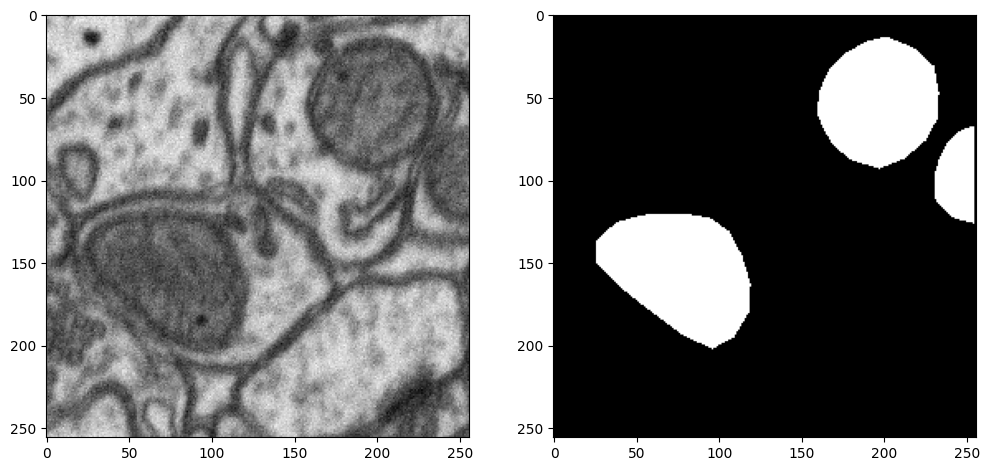

In [10]:
#Sanity Check if the images are correct
import random
image_number = random.randint(0,len(X_train))

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(np.reshape(X_train[image_number],(256,256)),cmap='gray')

plt.subplot(122)
plt.imshow(np.reshape(y_train[image_number],(256,256)),cmap='gray')

print(image_number)

In [11]:
# Extract the dimensions of the images for the model

IMG_HEIGHT = images.shape[1]
IMG_WIDTH  = images.shape[2]
IMG_CHANNELS = images.shape[3]

In [12]:
input_shape = (IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)

In [14]:
# THIS IS THE ENTIRE BLOCK OF CODE

# Import the necessary:
from keras.models import Model
from keras.layers import Input, Conv2D, Activation, BatchNormalization, MaxPooling2D, UpSampling2D, Concatenate, Conv2DTranspose
# from keras.optimizers import Adam

# Write the different blocks:
def conv_block(input,num_filters):
  x = Conv2D(num_filters,3,padding="same")(input)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  x = Conv2D(num_filters,3,padding="same")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)

  return x


def encoding_block(input,num_filters):
  x = conv_block(input,num_filters)
  p = MaxPooling2D((2,2))(x)

  return x,p


def decoding_block(input, skip_features,num_filters):
  x = Conv2DTranspose(num_filters,(2,2),strides=2,padding="same")(input)
  x = Concatenate()([x,skip_features])
  x = conv_block(x,num_filters)
  return x


# Building the UNet:
def build_unet(input_shape):
  inputs = Input(input_shape)

  s1,p1 = encoding_block(inputs,64)
  s2,p2 = encoding_block(p1,128)
  s3,p3 = encoding_block(p2,256)
  s4,p4 = encoding_block(p3,512)

  b1 = conv_block(p4,1024)

  d1 = decoding_block(b1,s4,512)
  d2 = decoding_block(d1,s3,256)
  d3 = decoding_block(d2,s2,128)
  d4 = decoding_block(d3,s1,64)

  outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

  model = Model(inputs,outputs, name="U-Net")
  return model


In [17]:
model = build_unet(input_shape)
model.compile(optimizer=Adam(learning_rate = 1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_20[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_23[0][0] 

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

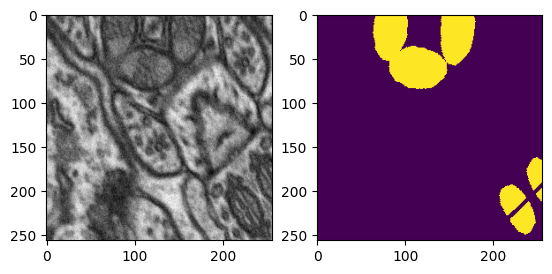

In [35]:
# Prep Image Augmnetation and Generation

#New generator with rotation and shear where interpolation that comes with rotation and shear are thresholded in masks.
#This gives a binary mask rather than a mask with interpolated values.

seed=24

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_data_gen_args = dict(rotation_range=90,
                     width_shift_range=0.3,
                     height_shift_range=0.3,
                     shear_range=0.5,
                     zoom_range=0.3,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')

mask_data_gen_args = dict(rotation_range=90,
                     width_shift_range=0.3,
                     height_shift_range=0.3,
                     shear_range=0.5,
                     zoom_range=0.3,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect',
                     preprocessing_function = lambda x: np.where(x>0, 1, 0).astype(x.dtype)) #Binarize the output again.

image_data_generator = ImageDataGenerator(**img_data_gen_args)
#image_data_generator.fit(X_train, augment=True, seed=seed)

batch_size= 8

image_generator = image_data_generator.flow(X_train, seed=seed, batch_size=batch_size)
valid_img_generator = image_data_generator.flow(X_test, seed=seed, batch_size=batch_size) #Default batch size 32, if not specified here


mask_data_generator = ImageDataGenerator(**mask_data_gen_args)
mask_generator = mask_data_generator.flow(y_train, seed=seed, batch_size=batch_size)
valid_mask_generator = mask_data_generator.flow(y_test, seed=seed, batch_size=batch_size)  #Default batch size 32, if not specified here


def my_image_mask_generator(image_generator, mask_generator):
    train_generator = zip(image_generator, mask_generator)
    for (img, mask) in train_generator:
        yield (img, mask)

my_generator = my_image_mask_generator(image_generator, mask_generator)

validation_datagen = my_image_mask_generator(valid_img_generator, valid_mask_generator)


x = next(image_generator)
y = next(mask_generator)
for i in range(0,1):
    image = x[i]
    mask = y[i]
    plt.subplot(1,2,1)
    plt.imshow(image[:,:,0], cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(mask[:,:,0])
    plt.show()



In [ ]:
steps_per_epoch = 3*(len(X_train))//batch_size


history = model.fit(my_generator, validation_data=validation_datagen,
                    steps_per_epoch=steps_per_epoch,
                    validation_steps=steps_per_epoch, epochs=25)


#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 53s/step - accuracy: 0.8608 - loss: 0.3425 